In [1]:
from pathlib import Path
import pandas as pd
import pyreadstat

ROOT = Path("../")
W1_INHOME = ROOT / "data" / "W1" / "w1inhome.sas7bdat"
W1_CONTEXT = ROOT / "data" / "W1" / "w1context.sas7bdat"
OUT_CSV = ROOT / "outputs" / "w1_confounder_candidates.csv"

CATEGORIES = {
    "Academic/Cognitive": ["grade", "school", "learn", "special education", "repeat"],
    "Health/Physical": ["health", "weight", "height", "illness", "disability", "sleep", "doctor"],
    "Health/Mental": ["depress", "sad", "happy", "esteem", "cry", "counsel", "psych"],
    "Risk Behaviors": ["smoke", "cigarette", "alcohol", "drink", "drug", "marijuana", "arrest", "trouble", "police"],
    "SES/Financial": ["income", "educat", "welfare", "pay", "money", "afford", "food stamp"],
    "Family/Home": ["parent", "mother", "father", "live with", "born", "sibling"],
    "Demographics": ["race", "hispanic", "age", "sex", "gender"],
}

def search_labels(path: Path, source_name: str) -> list:
    print(f"Reading metadata for {source_name}...")
    _, meta = pyreadstat.read_sas7bdat(str(path), metadataonly=True)
    labels = meta.column_names_to_labels
    
    hits = []
    for var, label in labels.items():
        if not label: continue
        label_lower = label.lower()
        
        # Check against categories
        matched_cats = []
        for cat, keywords in CATEGORIES.items():
            if any(kw in label_lower for kw in keywords):
                matched_cats.append(cat)
                
        if matched_cats:
            hits.append({
                "Source": source_name,
                "Variable": var,
                "Label": label,
                "Categories": ", ".join(matched_cats)
            })
    return hits

hits = []
if W1_INHOME.exists():
    hits.extend(search_labels(W1_INHOME, "w1_inhome"))
if W1_CONTEXT.exists():
    hits.extend(search_labels(W1_CONTEXT, "w1_context"))
        
df = pd.DataFrame(hits)
df.to_csv(OUT_CSV, index=False)
print(f"Found {len(df)} candidate confounders! Saved to {OUT_CSV.name}")


Reading metadata for w1_inhome...
Reading metadata for w1_context...
Found 862 candidate confounders! Saved to w1_confounder_candidates.csv


In [2]:
import pandas as pd
from pathlib import Path

ROOT = Path("../")
IN_CSV = ROOT / "outputs" / "w1_confounder_candidates.csv"
OUT_CSV = ROOT / "outputs" / "w1_final_confounders.csv"

FINAL_CONFOUNDERS = [
    # Demographics
    "BIO_SEX", "PA2", "H1GI8", "H1GI11", 
    # SES & Household
    "PA55", "PA12", "PA57D",
    # Baseline Cognitive & Academic
    "AH_PVT", "H1ED5", "PC38", "PC39",
    # Baseline Health & Risk (Keep it binary/high-level to avoid missingness)
    "H1GH1", "PC53", "H1TO1", "H1TO12",
    # Environment & Contextual Context
    "H1NB5", "BST90P01", "BST90P15"
]

if not IN_CSV.exists():
    print(f"Cannot find {IN_CSV}")

# Load the big candidate list
df = pd.read_csv(IN_CSV)
    
# Filter only for our final curated list
final_df = df[df["Variable"].isin(FINAL_CONFOUNDERS)].copy()

# Group them nicely
final_df.sort_values(by=["Source", "Variable"], inplace=True)
    
# Save the polished list
final_df.to_csv(OUT_CSV, index=False)
    
print(f"Successfully extracted {len(final_df)} highly relevant confounders!")
print(f"Saved to: {OUT_CSV.name}")
    
# Print them out to the console for a quick sanity check
print("\n--- Final Confounder List ---")
for _, row in final_df.iterrows():
    print(f"[{row['Source']}] {row['Variable']}: {row['Label']}")


Successfully extracted 16 highly relevant confounders!
Saved to: w1_final_confounders.csv

--- Final Confounder List ---
[w1_context] BST90P15: Median Household Income
[w1_inhome] AH_PVT: ADD HEALTH PICTURE VOCABULARY TEST SCORE
[w1_inhome] BIO_SEX: BIOLOGICAL SEX-W1
[w1_inhome] H1ED5: S5Q5 HAVE YOU EVER REPEATED A GRADE-W1
[w1_inhome] H1GH1: S3Q1 GENERAL HEALTH-W1
[w1_inhome] H1GI11: S1Q11 BORN IN THE UNITED STATES-W1
[w1_inhome] H1GI8: S1Q8 RACE-SINGLE CATEGORY-W1
[w1_inhome] H1TO1: S28Q1 EVER SMOKED A CIGARETTE-W1
[w1_inhome] H1TO12: S280Q12 DRINK ALCOHOL > 2-3 TIMES-W1
[w1_inhome] PA12: A12 LEVEL OF EDUCATION-PQ
[w1_inhome] PA2: A2 AGE OF RESPONDENT-PQ
[w1_inhome] PA55: A55 TOTAL HOUSEHOLD INCOME-PQ
[w1_inhome] PA57D: A57D RECEIVE FOOD STAMPS-PQ
[w1_inhome] PC38: C38 LEARNING DISABILITY-PQ
[w1_inhome] PC39: C39 SPECIAL EDUCATION-PQ
[w1_inhome] PC53: C53 CONSIDER A DISABILITY-PQ


In [3]:
import pandas as pd
import numpy as np
import pyreadstat
from pathlib import Path

ROOT = Path("../")
W1_NETWORK = ROOT / "data" / "W1" / "w1network.sas7bdat"

print("Loading W1 network data...")
df_net, meta_net = pyreadstat.read_sas7bdat(str(W1_NETWORK))

net_vars = ['AID', 'IDGX2', 'ODGX2', 'BCENT10X']
df_treatment = df_net[net_vars].copy()

for col in ['IDGX2', 'ODGX2', 'BCENT10X']:
    df_treatment[col] = pd.to_numeric(df_treatment[col], errors='coerce')

# Keep network-missing respondents as NaN treatment to avoid misclassifying them as controls.
observed_network = df_treatment[['IDGX2', 'ODGX2', 'BCENT10X']].notna().all(axis=1)
df_treatment['T_Network_Observed'] = observed_network.astype(int)

df_treatment['T_Strict_Isolation'] = np.nan
df_treatment['T_Zero_InDegree'] = np.nan
df_treatment['T_High_Centrality'] = np.nan

df_treatment.loc[observed_network, 'T_Strict_Isolation'] = np.where(
    (df_treatment.loc[observed_network, 'IDGX2'] == 0) & (df_treatment.loc[observed_network, 'ODGX2'] == 0), 1, 0
)
df_treatment.loc[observed_network, 'T_Zero_InDegree'] = np.where(
    df_treatment.loc[observed_network, 'IDGX2'] == 0, 1, 0
)

# Main treatment split for centrality: above observed-network median (treated) vs lower/equal (control).
med_cent = df_treatment.loc[observed_network, 'BCENT10X'].median()
df_treatment.loc[observed_network, 'T_High_Centrality'] = np.where(
    df_treatment.loc[observed_network, 'BCENT10X'] > med_cent, 1, 0
)

print("\n--- Treatment Group Distributions (Observed network only) ---")
for t_col in ["T_Strict_Isolation", "T_Zero_InDegree", "T_High_Centrality"]:
    counts = df_treatment.loc[observed_network, t_col].value_counts(dropna=False)
    print(f"\n{t_col}:")
    print(f"  0 (Control): {int(counts.get(0.0, 0))}")
    print(f"  1 (Treated): {int(counts.get(1.0, 0))}")

print("\nT_High_Centrality definition: 1 if BCENT10X > observed-network median; 0 otherwise.")
print(f"Observed-network median BCENT10X: {med_cent:.3f}")
print(f"Network exposure observed for {observed_network.sum()} / {len(df_treatment)} respondents.")

Loading W1 network data...

--- Treatment Group Distributions (Observed network only) ---

T_Strict_Isolation:
  0 (Control): 4244
  1 (Treated): 153

T_Zero_InDegree:
  0 (Control): 4020
  1 (Treated): 377

T_High_Centrality:
  0 (Control): 2199
  1 (Treated): 2198

T_High_Centrality definition: 1 if BCENT10X > observed-network median; 0 otherwise.
Observed-network median BCENT10X: 0.725
Network exposure observed for 4397 / 6504 respondents.


In [4]:
import pandas as pd
import numpy as np
import pyreadstat
from pathlib import Path

ROOT = Path("../")
W4_INHOME = ROOT / "data" / "W4" / "w4inhome.sas7bdat"

# Load W4 Data
print("Loading W4 data...")
df_w4, _ = pyreadstat.read_sas7bdat(str(ROOT / "data" / "W4" / "w4inhome.sas7bdat"))
df_w4['AID'] = df_w4['AID'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

# Load W5 Data
print("Loading W5 data...")
df_w5, _ = pyreadstat.read_xport(str(ROOT / "data" / "W5" / "pwave5.xpt"))
df_w5['AID'] = df_w5['AID'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

# Extract and standardize W4
df_out_w4 = df_w4[['AID', 'C4WD90_1', 'C4WD60_1', 'C4NUMSCR']].copy()
for col in ['C4WD90_1', 'C4WD60_1']: df_out_w4[col] = pd.to_numeric(df_out_w4[col], errors='coerce').where(lambda x: x.between(0, 15))
df_out_w4['C4NUMSCR'] = pd.to_numeric(df_out_w4['C4NUMSCR'], errors='coerce').where(lambda x: x.between(0, 7))

z_w4 = [(df_out_w4[c] - df_out_w4[c].mean()) / df_out_w4[c].std() for c in ['C4WD90_1', 'C4WD60_1', 'C4NUMSCR']]
df_out_w4['W4_COG_COMP'] = pd.concat(z_w4, axis=1).mean(axis=1, skipna=True)

# Extract and standardize W5
# Note: Adjust logic if you have derived a W5 NUMSCR equivalent (e.g. from H5MH3A-H5MH9B)
df_out_w5 = df_w5[['AID', 'C5WD90_1', 'C5WD60_1']].copy()
for col in ['C5WD90_1', 'C5WD60_1']: df_out_w5[col] = pd.to_numeric(df_out_w5[col], errors='coerce').where(lambda x: x.between(0, 15))

z_w5 = [(df_out_w5[c] - df_out_w5[c].mean()) / df_out_w5[c].std() for c in ['C5WD90_1', 'C5WD60_1']]
df_out_w5['W5_COG_COMP'] = pd.concat(z_w5, axis=1).mean(axis=1, skipna=True)

# Merge outcomes together
df_outcome = pd.merge(df_out_w4, df_out_w5, on='AID', how='outer')

Loading W4 data...
Loading W5 data...


In [5]:
import pandas as pd
import pyreadstat
from pathlib import Path

ROOT = Path("../")
W1_INHOME = ROOT / "data" / "W1" / "w1inhome.sas7bdat"
W1_CONTEXT = ROOT / "data" / "W1" / "w1context.sas7bdat"
CANDIDATE_CSV = ROOT / "outputs" / "w1_confounder_candidates.csv"

print("Loading Confounder Data...")
df_inhome, _ = pyreadstat.read_sas7bdat(str(W1_INHOME))
df_context, _ = pyreadstat.read_sas7bdat(str(W1_CONTEXT))

INHOME_CORE_CONFOUNDERS = [
    "BIO_SEX", "PA2", "H1GI8", "H1GI11", "PA55", "PA12", "PA57D",
    "AH_PVT", "H1ED5", "PC38", "PC39", "H1GH1", "PC53", "H1TO1",
    "H1TO12", "H1NB5"
]
CONTEXT_CORE_CONFOUNDERS = ["BST90P01", "BST90P15"]

# Pull extra baseline confounders from the metadata-screened candidate file.
EXTRA_CATEGORY_PRIORITY = [
    "SES/Financial",
    "Family/Home",
    "Health/Mental",
    "Academic/Cognitive",
    "Health/Physical",
    "Demographics",
    "Risk Behaviors",
]
MAX_EXTRA_PER_SOURCE = 12

def unique_preserve(seq):
    return list(dict.fromkeys(seq))

extra_inhome = []
extra_context = []

if CANDIDATE_CSV.exists():
    cand = pd.read_csv(CANDIDATE_CSV)
    cand["Source"] = cand["Source"].astype(str).str.lower()
    cand["Categories"] = cand["Categories"].fillna("").astype(str)

    for source_name, core_vars in [
        ("w1_inhome", INHOME_CORE_CONFOUNDERS),
        ("w1_context", CONTEXT_CORE_CONFOUNDERS),
    ]:
        src = cand[cand["Source"] == source_name].copy()
        src = src[~src["Variable"].isin(core_vars)]
        cat_mask = src["Categories"].apply(
            lambda txt: any(cat in txt for cat in EXTRA_CATEGORY_PRIORITY)
        )
        src = src[cat_mask].drop_duplicates("Variable")
        picked = src["Variable"].head(MAX_EXTRA_PER_SOURCE).tolist()
        if source_name == "w1_inhome":
            extra_inhome = picked
        else:
            extra_context = picked

inhome_selected = unique_preserve(
    INHOME_CORE_CONFOUNDERS + [v for v in extra_inhome if v in df_inhome.columns]
 )
context_selected = unique_preserve(
    CONTEXT_CORE_CONFOUNDERS + [v for v in extra_context if v in df_context.columns]
 )

df_inhome_conf = df_inhome[['AID'] + inhome_selected].copy()
df_context_conf = df_context[['AID'] + context_selected].copy()

def decode_aid(series):
    if pd.api.types.is_object_dtype(series):
        return series.apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))
    return series.astype(str)

print("Decoding AIDs for merging...")
df_treatment['AID'] = decode_aid(df_treatment['AID'])
df_outcome['AID'] = decode_aid(df_outcome['AID'])
df_inhome_conf['AID'] = decode_aid(df_inhome_conf['AID'])
df_context_conf['AID'] = decode_aid(df_context_conf['AID'])

print("Merging dataframes...")
causal_df = df_treatment[['AID', 'T_Network_Observed', 'T_Strict_Isolation', 'T_Zero_InDegree', 'T_High_Centrality']].copy()

causal_df = pd.merge(
    causal_df,
    df_outcome[['AID', 'C4WD90_1', 'C4WD60_1', 'C4NUMSCR', 'W4_COG_COMP', 'C5WD90_1', 'C5WD60_1', 'W5_COG_COMP']],
    on='AID',
    how='inner'
 )
causal_df = pd.merge(causal_df, df_inhome_conf, on='AID', how='inner')
causal_df = pd.merge(causal_df, df_context_conf, on='AID', how='left')

print(f"\nFinal Merged DataFrame Shape: {causal_df.shape}")
print(f"Number of W1 respondents successfully matched to W4: {len(causal_df)}")
print(f"Core in-home confounders kept: {len(INHOME_CORE_CONFOUNDERS)}")
print(f"Extra in-home confounders kept: {len(inhome_selected) - len(INHOME_CORE_CONFOUNDERS)}")
print(f"Core context confounders kept: {len(CONTEXT_CORE_CONFOUNDERS)}")
print(f"Extra context confounders kept: {len(context_selected) - len(CONTEXT_CORE_CONFOUNDERS)}")
print("\nColumns in `causal_df`:")
print(causal_df.columns.tolist())

causal_df.head()

Loading Confounder Data...
Decoding AIDs for merging...
Merging dataframes...

Final Merged DataFrame Shape: (5597, 53)
Number of W1 respondents successfully matched to W4: 5597
Core in-home confounders kept: 16
Extra in-home confounders kept: 12
Core context confounders kept: 2
Extra context confounders kept: 11

Columns in `causal_df`:
['AID', 'T_Network_Observed', 'T_Strict_Isolation', 'T_Zero_InDegree', 'T_High_Centrality', 'C4WD90_1', 'C4WD60_1', 'C4NUMSCR', 'W4_COG_COMP', 'C5WD90_1', 'C5WD60_1', 'W5_COG_COMP', 'BIO_SEX', 'PA2', 'H1GI8', 'H1GI11', 'PA55', 'PA12', 'PA57D', 'AH_PVT', 'H1ED5', 'PC38', 'PC39', 'H1GH1', 'PC53', 'H1TO1', 'H1TO12', 'H1NB5', 'SCH_YR', 'SMP03', 'H1GI3', 'H1GI4', 'H1GI5A', 'H1GI5B', 'H1GI5C', 'H1GI5D', 'H1GI5E', 'H1GI5F', 'H1GI6A', 'H1GI6B', 'BST90P01', 'BST90P15', 'BST90P02', 'BST90P03', 'BST90P04', 'BST90P05', 'BST90P06', 'BST90P07', 'BST90P16', 'BST90P17', 'BST90P18', 'BST90P20', 'BST90P21']


,AID,T_Network_Observed,T_Strict_Isolation,T_Zero_InDegree,T_High_Centrality,C4WD90_1,C4WD60_1,C4NUMSCR,W4_COG_COMP,C5WD90_1,...,BST90P03,BST90P04,BST90P05,BST90P06,BST90P07,BST90P16,BST90P17,BST90P18,BST90P20,BST90P21
0,57101310,0,NaN,NaN,NaN,11.0,9.0,3.0,1.075152,NaN,...,0.014,1.0,2.0,36.0,0.983,0.938,17000.0,0.947,2.0,0.838
1,57103869,0,NaN,NaN,NaN,3.0,3.0,2.0,-1.442256,NaN,...,0.161,1.0,2.0,36.0,0.985,0.933,21000.0,0.966,2.0,0.887
2,57109625,0,NaN,NaN,NaN,6.0,4.0,6.0,0.086128,NaN,...,0.032,1.0,2.0,35.0,0.969,0.897,49000.0,0.844,2.0,0.932
3,57111071,0,NaN,NaN,NaN,6.0,6.0,7.0,0.624797,NaN,...,0.010,1.0,2.0,35.0,0.980,0.941,38000.0,0.903,2.0,0.919
4,57111786,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,0.382,1.0,2.0,31.0,0.913,0.818,46000.0,0.812,3.0,0.860


In [6]:
# Reserve-code cleanup across numeric columns before modeling.
# This avoids treating survey missing/reserve codes as valid numeric values.
RESERVE_CODES = {995, 996, 997, 998, 999, 9995, 9996, 9997, 9998, 9999}
numeric_cols = causal_df.select_dtypes(include=[np.number]).columns.tolist()

n_replaced_total = 0
for c in numeric_cols:
    n_matches = causal_df[c].isin(RESERVE_CODES).sum()
    if n_matches > 0:
        causal_df.loc[causal_df[c].isin(RESERVE_CODES), c] = np.nan
        n_replaced_total += int(n_matches)

print(f"Reserve-code cleanup complete: replaced {n_replaced_total} coded values across {len(numeric_cols)} numeric columns.")

Reserve-code cleanup complete: replaced 1561 coded values across 52 numeric columns.


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Target population for primary estimand: respondents with observed network exposure.
# Main exposure contrast: high Bonacich-style centrality (> observed-network median) vs lower/equal centrality.
analytic_df = causal_df[causal_df['T_Network_Observed'] == 1].copy()

# Treat missing cognitive composite as outcome missingness.
analytic_df['Y_observed'] = analytic_df['W4_COG_COMP'].notna().astype(int)

print(f"Rows in target population (network observed, median split): {len(analytic_df)}")
print(f"Outcome observed rate in target population: {analytic_df['Y_observed'].mean():.3f}")

print("Loading W4 and W5 Weights and Clusters...")

df_w4_weights, _ = pyreadstat.read_sas7bdat(str(ROOT / "data" / "W4" / "w4weight.sas7bdat"))
df_w5_weights, _ = pyreadstat.read_xport(str(ROOT / "data" / "W5" / "p5weight.xpt"))

# Decode AIDs
df_w4_weights['AID'] = df_w4_weights['AID'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))
df_w5_weights['AID'] = df_w5_weights['AID'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

# Merge W4 and W5 weights using correct column names
df_weights = pd.merge(
    df_w4_weights[['AID', 'GSWGT4_2', 'CLUSTER2']], 
    df_w5_weights[['AID', 'GSW5']], 
    on='AID', how='outer'
)

# Merge into analytic_df
analytic_df = pd.merge(causal_df[causal_df['T_Network_Observed'] == 1], df_weights, on='AID', how='inner')

print(f"\nAnalytic dataset shape: {analytic_df.shape}")
print(f"W4_COG_COMP available: {analytic_df['W4_COG_COMP'].notna().sum()}")
print(f"W5_COG_COMP available: {analytic_df['W5_COG_COMP'].notna().sum()}")

# Baseline covariate encoding only (no MODE terms).
categorical_cols = ['H1GI8', 'BST90P01']
for col in categorical_cols:
    if col in analytic_df.columns:
        analytic_df[col] = analytic_df[col].astype('category')
analytic_df = pd.get_dummies(analytic_df, columns=[c for c in categorical_cols if c in analytic_df.columns], drop_first=True)

treatment_cols = ['T_Strict_Isolation', 'T_Zero_InDegree', 'T_High_Centrality']
outcome_cols = ['C4WD90_1', 'C4WD60_1', 'C4NUMSCR', 'W4_COG_COMP', 'C5WD90_1', 'C5WD60_1', 'W5_COG_COMP']
meta_cols = ['AID', 'GSWGT4_2', 'GSW5', 'CLUSTER2', 'T_Network_Observed', 'Y_observed']

# Guardrail: exclude post-treatment MODE dummies if they appear.
post_treatment_cols = [c for c in analytic_df.columns if c.startswith('MODE_')]
confounder_cols = [
    c for c in analytic_df.columns
    if c not in treatment_cols + outcome_cols + meta_cols + post_treatment_cols
]

# Data-adaptive trimming: remove near-empty and near-constant covariates.
missing_rate = analytic_df[confounder_cols].isna().mean()
high_missing = missing_rate[missing_rate > 0.45].index.tolist()
if high_missing:
    confounder_cols = [c for c in confounder_cols if c not in high_missing]
near_constant = [c for c in confounder_cols if analytic_df[c].nunique(dropna=True) <= 1]
if near_constant:
    confounder_cols = [c for c in confounder_cols if c not in near_constant]

print(f"Confounders selected: {len(confounder_cols)}")



Rows in target population (network observed, median split): 3844
Outcome observed rate in target population: 0.913
Loading W4 and W5 Weights and Clusters...

Analytic dataset shape: (3844, 56)
W4_COG_COMP available: 3510
W5_COG_COMP available: 394
Confounders selected: 50


In [8]:
# DIAGNOSTIC: Check W5 weights file structure
print("=== W4 Weight Columns ===")
df_w4_weights_diag, _ = pyreadstat.read_sas7bdat(str(ROOT / "data" / "W4" / "w4weight.sas7bdat"))
print("Columns:", df_w4_weights_diag.columns.tolist())
print(f"Shape: {df_w4_weights_diag.shape}\n")

print("=== W5 Weight Columns ===")
df_w5_weights_diag, _ = pyreadstat.read_xport(str(ROOT / "data" / "W5" / "p5weight.xpt"))
print("Columns:", df_w5_weights_diag.columns.tolist())
print(f"Shape: {df_w5_weights_diag.shape}")


=== W4 Weight Columns ===
Columns: ['AID', 'CLUSTER2', 'GSWGT4', 'GSWGT4_2', 'GSWGT134']
Shape: (5114, 5)

=== W5 Weight Columns ===
Columns: ['AID', 'CLUSTER2', 'GSW5', 'GSW12345', 'GSW1345', 'GSW145']
Shape: (4196, 6)


In [9]:
analytic_df

,AID,T_Network_Observed,T_Strict_Isolation,T_Zero_InDegree,T_High_Centrality,C4WD90_1,C4WD60_1,C4NUMSCR,W4_COG_COMP,C5WD90_1,...,H1GI8_3.0,H1GI8_4.0,H1GI8_5.0,H1GI8_6.0,H1GI8_7.0,H1GI8_8.0,H1GI8_9.0,BST90P01_2.0,BST90P01_8.0,BST90P01_9.0
0,90316053,1,0.0,0.0,1.0,7.0,6.0,7.0,0.791650,NaN,...,False,False,False,False,True,False,False,False,False,False
1,90316656,1,0.0,0.0,1.0,5.0,3.0,6.0,-0.241703,NaN,...,False,False,False,False,True,False,False,False,False,False
2,90500059,1,0.0,0.0,1.0,10.0,9.0,7.0,1.775145,NaN,...,False,False,False,False,True,False,False,False,False,False
3,90500459,1,0.0,0.0,0.0,5.0,4.0,3.0,-0.730860,NaN,...,False,False,False,False,True,False,False,False,False,False
4,90500516,1,0.0,0.0,1.0,8.0,5.0,3.0,-0.069322,NaN,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3839,99718925,1,0.0,0.0,1.0,5.0,3.0,1.0,-1.325262,4.0,...,False,False,False,False,True,False,False,True,False,False
3840,99718944,1,0.0,0.0,0.0,7.0,5.0,3.0,-0.236175,NaN,...,False,False,False,False,True,False,False,True,False,False
3841,99719930,1,0.0,0.0,1.0,5.0,3.0,5.0,-0.458415,NaN,...,False,False,False,False,True,False,False,True,False,False
3842,99719939,1,0.0,0.0,0.0,5.0,4.0,3.0,-0.730860,NaN,...,False,False,False,False,True,False,False,True,False,False


In [10]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import scipy.stats as stats
import numpy as np
import pandas as pd


def fit_aipw(
    df,
    confounder_cols,
    treatment_col,
    outcome_col,
    weight_col,
    random_state=42,
    clip=0.05,
):
    """Non-cross-fitted AIPW for a binary treatment with survey/observation weights."""
    df = df.dropna(subset=[outcome_col]).copy()
    X_local = df[confounder_cols].to_numpy()
    T_local = df[treatment_col].astype(int).to_numpy()
    Y_local = df[outcome_col].to_numpy()
    W_local = df[weight_col].to_numpy()

    # Single impute/scale pass on the full sample.
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_local)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    if np.unique(T_local).size < 2:
        raise ValueError("Treatment is single-class after filtering.")

    # Propensity model P(T=1|X).
    ps_model = LogisticRegression(max_iter=3000, random_state=random_state)
    ps_model.fit(X_scaled, T_local, sample_weight=W_local)
    e_hat = np.clip(ps_model.predict_proba(X_scaled)[:, 1], clip, 1 - clip)

    # Outcome models E[Y|T=1,X] and E[Y|T=0,X].
    t1_mask = T_local == 1
    t0_mask = T_local == 0
    if t1_mask.sum() < 5 or t0_mask.sum() < 5:
        raise ValueError("Too few treated or control observations for outcome models.")

    out_model_1 = LinearRegression().fit(
        X_scaled[t1_mask],
        Y_local[t1_mask],
        sample_weight=W_local[t1_mask],
    )
    out_model_0 = LinearRegression().fit(
        X_scaled[t0_mask],
        Y_local[t0_mask],
        sample_weight=W_local[t0_mask],
    )

    m1_hat = out_model_1.predict(X_scaled)
    m0_hat = out_model_0.predict(X_scaled)

    valid_mask = np.isfinite(e_hat) & np.isfinite(m1_hat) & np.isfinite(m0_hat)
    if valid_mask.sum() < int(0.95 * len(df)):
        raise ValueError("Too few valid AIPW predictions after model fitting.")

    T_valid = T_local[valid_mask]
    Y_valid = Y_local[valid_mask]
    W_valid = W_local[valid_mask]
    e_valid = e_hat[valid_mask]
    m1_valid = m1_hat[valid_mask]
    m0_valid = m0_hat[valid_mask]

    dr1_valid = m1_valid + (T_valid * (Y_valid - m1_valid) / e_valid)
    dr0_valid = m0_valid + ((1 - T_valid) * (Y_valid - m0_valid) / (1 - e_valid))
    individual_te_valid = dr1_valid - dr0_valid
    ate_local = np.average(individual_te_valid, weights=W_valid)

    individual_te = pd.Series(np.nan, index=df.index, dtype=float)
    individual_te.iloc[valid_mask] = individual_te_valid

    return {
        'ate': float(ate_local),
        'ps_scores': e_hat,
        'individual_te': individual_te,
        'valid_mask': valid_mask,
    }


def bootstrap_cluster_aipw(df, outcome_col, weight_col, confounders, n_boot=2000, random_state=42):
    """Cluster bootstrap percentile CI for the non-cross-fitted AIPW estimate."""
    rng = np.random.default_rng(random_state)
    base_df = df.dropna(subset=[outcome_col, weight_col, 'CLUSTER2']).copy()
    clusters = base_df['CLUSTER2'].dropna().unique().tolist()
    if len(clusters) < 2:
        raise ValueError("Need at least 2 clusters for cluster bootstrap inference.")

    cluster_to_idx = {
        cluster: base_df.index[base_df['CLUSTER2'] == cluster].tolist()
        for cluster in clusters
    }

    boot_ates = []
    for b in range(n_boot):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        sampled_idx = []
        for cluster in sampled_clusters:
            sampled_idx.extend(cluster_to_idx[cluster])

        boot_df = base_df.loc[sampled_idx].copy()
        boot_df = boot_df.reset_index(drop=True)

        # Recompute AIPW inside each bootstrap resample.
        boot_fit = fit_aipw(
            boot_df,
            confounder_cols=confounders,
            treatment_col='T_High_Centrality',
            outcome_col=outcome_col,
            weight_col=weight_col,
            random_state=random_state + b + 1,
        )
        boot_ates.append(boot_fit['ate'])

    boot_ates = np.asarray(boot_ates, dtype=float)
    se = float(np.nanstd(boot_ates, ddof=1))
    ci_lo, ci_hi = np.nanpercentile(boot_ates, [2.5, 97.5])

    return {
        'se': se,
        'ci_lo': float(ci_lo),
        'ci_hi': float(ci_hi),
        'boot_ates': boot_ates,
        'n_boot': int(n_boot),
    }


def run_analysis_for_wave(df, outcome_col, weight_col, confounders):
    """Run non-cross-fitted AIPW and bootstrap sensitivity analysis for a single wave."""
    wave_df = df.dropna(subset=[outcome_col, weight_col]).copy()

    # 1. Run AIPW.
    fit_res = fit_aipw(
        wave_df,
        confounder_cols=confounders,
        treatment_col='T_High_Centrality',
        outcome_col=outcome_col,
        weight_col=weight_col,
    )

    ate = fit_res['ate']

    # 2. Cluster bootstrap uncertainty.
    boot_res = bootstrap_cluster_aipw(
        wave_df,
        outcome_col=outcome_col,
        weight_col=weight_col,
        confounders=confounders,
        n_boot=4000,
        random_state=42,
    )
    se = boot_res['se']
    ci_lo = boot_res['ci_lo']
    ci_hi = boot_res['ci_hi']

    # Bootstrap two-sided p-value computed directly from the bootstrap
    # distribution: 2 * min(P(boot <= 0), P(boot >= 0)). The +1/(B+1)
    # adjustment avoids exact-zero p-values.
    boot_ates_arr = boot_res['boot_ates']
    boot_finite = boot_ates_arr[np.isfinite(boot_ates_arr)]
    if boot_finite.size > 0:
        n_b = boot_finite.size
        p_left = (np.sum(boot_finite <= 0) + 1) / (n_b + 1)
        p_right = (np.sum(boot_finite >= 0) + 1) / (n_b + 1)
        p_value = float(min(1.0, 2 * min(p_left, p_right)))
    else:
        p_value = float('nan')

    # Sensitivity benchmark markers (E-value).
    rr_star = np.exp(0.91 * abs(ate))
    e_value = rr_star + np.sqrt(rr_star * (rr_star - 1))

    return {
        "Wave": outcome_col.split("_")[0],
        "N": int(fit_res['valid_mask'].sum()),
        "ATE": round(ate, 4),
        "SE": round(se, 4),
        "95% CI": f"[{ci_lo:.4f}, {ci_hi:.4f}]",
        "P-value": round(p_value, 4),
        "E-value": round(e_value, 4),
    }


results = []
waves_config = [
    {'outcome': 'W4_COG_COMP', 'weight': 'GSWGT4_2'},
    {'outcome': 'W5_COG_COMP', 'weight': 'GSW5'}
]

for config in waves_config:
    if config['outcome'] in analytic_df.columns and analytic_df[config['outcome']].notna().sum() > 30:
        print(f"Running analysis for {config['outcome']}...")
        try:
            res = run_analysis_for_wave(analytic_df, config['outcome'], config['weight'], confounder_cols)
            results.append(res)
            print(f"✓ {config['outcome']} complete")
        except Exception as e:
            print(f"✗ {config['outcome']} failed: {str(e)}")
    else:
        n_valid = analytic_df[config['outcome']].notna().sum() if config['outcome'] in analytic_df.columns else 0
        print(f"Skipping {config['outcome']}: only {n_valid} valid values")

# Display final comparison table.
if results:
    results_df = pd.DataFrame(results)
    print("\n" + "=" * 120)
    print("AIPW RESULTS (W4 & W5)")
    print("=" * 120)
    display(results_df)
else:
    print("No results to display")


Running analysis for W4_COG_COMP...
✓ W4_COG_COMP complete
Running analysis for W5_COG_COMP...
✓ W5_COG_COMP complete

AIPW RESULTS (W4 & W5)


,Wave,N,ATE,SE,95% CI,P-value,E-value
0,W4,3510,0.0908,0.0483,"[0.0306, 0.1419]",0.0090,1.3921
1,W5,394,-0.0184,0.3027,"[-0.4105, 0.8705]",0.7443,1.1477


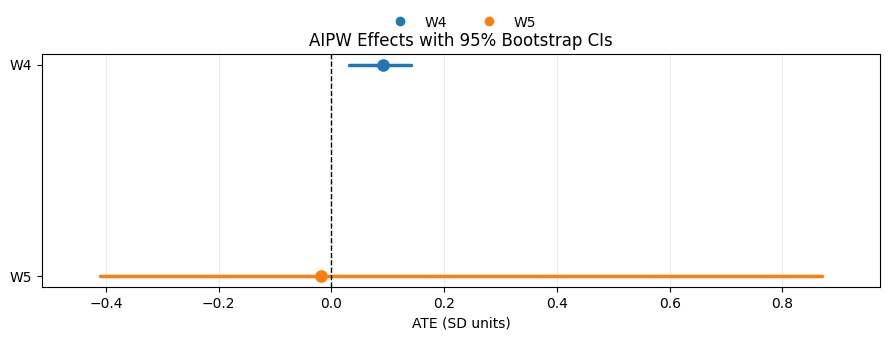


Partial R^2 sensitivity summary (continuous-outcome appropriate):


,Confounder set,Wave,ATE,SE,95% CI,N,t_stat,RV
0,Current set,W4,0.0908,0.0483,"[0.0306, 0.1419]",3510,1.880,0.031
1,Current set,W5,-0.0184,0.3027,"[-0.4105, 0.8705]",394,-0.061,0.003


In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

# Continuous-outcome sensitivity: partial R^2 robustness values (Cinelli & Hazlett style).
def _parse_ci(ci_text: str):
    vals = re.findall(r"[-+]?\d*\.?\d+", str(ci_text))
    if len(vals) < 2:
        return np.nan, np.nan
    return float(vals[0]), float(vals[1])


def _compute_rv(t_stat: float, dof: int):
    # RV_q: strength needed to explain away point estimate.
    f2 = (t_stat ** 2) / max(dof, 1)
    rv_q = 0.5 * (np.sqrt(f2 ** 2 + 4 * f2) - f2)
    return float(rv_q)


if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the AIPW results cell first.")

plot_df = results_df.copy()
if 'Confounder set' not in plot_df.columns:
    plot_df['Confounder set'] = 'Current set'

plot_df[['CI_low', 'CI_high']] = plot_df['95% CI'].apply(lambda x: pd.Series(_parse_ci(x)))
plot_df = plot_df.sort_values(['Confounder set', 'Wave']).reset_index(drop=True)

# Approximate model DoF for robustness values.
n_covariates = len(confounder_cols) if 'confounder_cols' in globals() else 1
plot_df['dof_approx'] = np.maximum(plot_df['N'] - n_covariates - 1, 30)
plot_df['t_stat'] = plot_df['ATE'] / plot_df['SE']
plot_df['RV'] = plot_df.apply(lambda r: _compute_rv(r['t_stat'], int(r['dof_approx'])), axis=1)

# -------- Plot: ATE + 95% CI for W4 and W5 --------
fig, ax = plt.subplots(figsize=(9, 3.6))

# Tighter vertical spacing so wave rows are closer together.
y = np.arange(len(plot_df)) * 0.55
labels = [f"{r['Wave']}" for _, r in plot_df.iterrows()]
colors = {'W4': '#1f77b4', 'W5': '#ff7f0e'}

for i, (_, row) in enumerate(plot_df.iterrows()):
    color = colors.get(row['Wave'], '#444444')
    ax.plot([row['CI_low'], row['CI_high']], [y[i], y[i]], color=color, lw=2.5, solid_capstyle='round')
    ax.scatter(row['ATE'], y[i], color=color, s=65, zorder=3)

ax.axvline(0, color='black', linestyle='--', lw=1)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('ATE (SD units)')
ax.set_title('AIPW Effects with 95% Bootstrap CIs')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25)

# Auto x-limits with gentle padding for readability.
x_min = float(plot_df['CI_low'].min())
x_max = float(plot_df['CI_high'].max())
x_pad = max((x_max - x_min) * 0.08, 0.03)
ax.set_xlim(x_min - x_pad, x_max + x_pad)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=8, label='W4'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=8, label='W5'),
]
# Place legend above the plot so it never covers CIs.
ax.legend(handles=handles, frameon=False, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.22))

plt.tight_layout()
plt.show()

# -------- Output sensitivity table --------
sens_cols = ['Confounder set', 'Wave', 'ATE', 'SE', '95% CI', 'N', 't_stat', 'RV']
print('\nPartial R^2 sensitivity summary (continuous-outcome appropriate):')
display(plot_df[sens_cols].round({'ATE': 4, 'SE': 4, 't_stat': 3, 'RV': 3}))

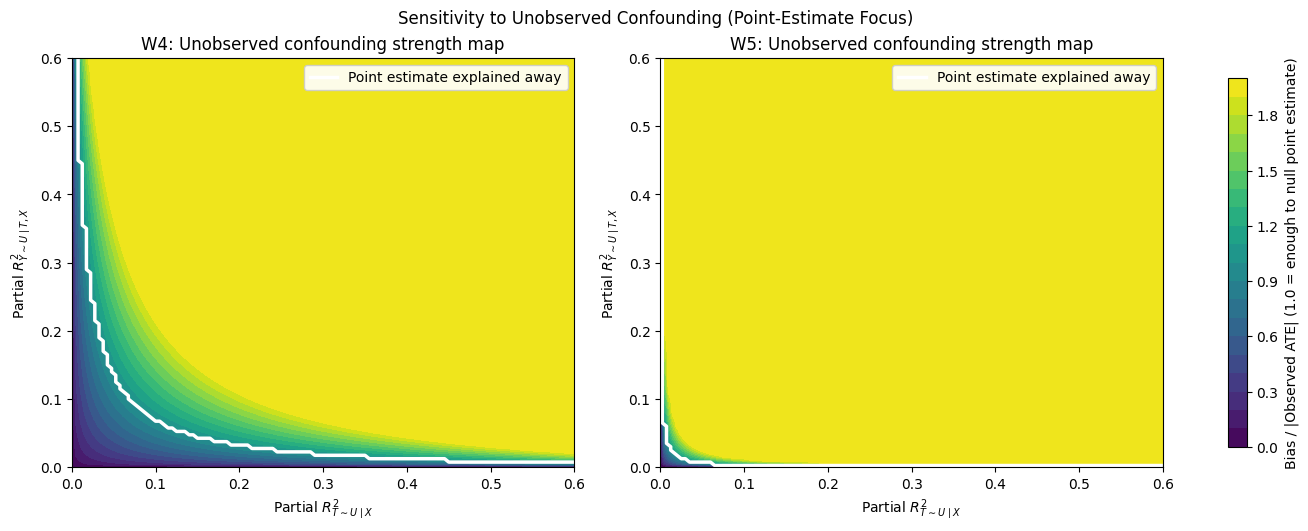


Sensitivity summary (equal-strength confounder benchmark):


,Wave,ATE,SE,Equal-strength R2 needed (point null),Equal-strength R2 needed (CI touches 0)
0,W4,0.0908,0.0483,0.085,0.0
1,W5,-0.0184,0.3027,0.020,0.0


In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Unobserved-confounding sensitivity map (continuous-outcome approximation).
# Interprets strength of an omitted confounder via two partial R^2 values:
# R2_TU = association with treatment | observed covariates
# R2_YU = association with outcome  | observed covariates

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    raise ValueError("results_df not found. Run the AIPW results cell first.")

def _parse_ci(ci_text: str):
    vals = re.findall(r"[-+]?\d*\.?\d+", str(ci_text))
    if len(vals) < 2:
        return np.nan, np.nan
    return float(vals[0]), float(vals[1])

plot_df_s = results_df.copy()
if 'Confounder set' in plot_df_s.columns:
    first_set = plot_df_s['Confounder set'].iloc[0]
    plot_df_s = plot_df_s[plot_df_s['Confounder set'] == first_set].copy()

plot_df_s[['CI_low', 'CI_high']] = plot_df_s['95% CI'].apply(lambda x: pd.Series(_parse_ci(x)))
required_cols = {'Wave', 'ATE', 'SE', 'CI_low', 'CI_high'}
missing_cols = required_cols - set(plot_df_s.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in results_df: {sorted(missing_cols)}")

waves = plot_df_s['Wave'].astype(str).tolist()
n_waves = len(waves)
if n_waves == 0:
    raise ValueError("No wave rows available in results_df for sensitivity plotting.")

# Grid over plausible unobserved-confounder strengths.
r2_vals = np.linspace(0.0, 0.6, 121)
R2_TU, R2_YU = np.meshgrid(r2_vals, r2_vals)

fig, axes = plt.subplots(1, n_waves, figsize=(6.5 * n_waves, 5.2), squeeze=False, constrained_layout=True)
axes = axes.ravel()

summary_rows = []

for i, (_, row) in enumerate(plot_df_s.iterrows()):
    ax = axes[i]
    wave = str(row['Wave'])
    ate0 = float(row['ATE'])
    se0 = float(row['SE'])
    ci_lo0 = float(row['CI_low'])
    ci_hi0 = float(row['CI_high'])

    # Approximate omitted-variable bias magnitude in SD units.
    with np.errstate(divide='ignore', invalid='ignore'):
        bias_surface = np.sqrt((R2_YU / (1 - R2_YU)) * (R2_TU / (1 - R2_TU)))
    bias_surface = np.nan_to_num(bias_surface, nan=np.inf, posinf=np.inf, neginf=np.inf)

    sign_eff = np.sign(ate0) if ate0 != 0 else 1.0
    ate_adj = ate0 - sign_eff * bias_surface

    # Region where confounding is strong enough to move point estimate to 0.
    explains_away = (sign_eff * ate_adj) <= 0

    ratio_to_point = bias_surface / max(abs(ate0), 1e-8)

    im = ax.contourf(
        R2_TU,
        R2_YU,
        np.clip(ratio_to_point, 0, 2.0),
        levels=np.linspace(0, 2, 21),
        cmap='viridis'
    )
    ax.contour(
        R2_TU, R2_YU, explains_away.astype(float), levels=[0.5],
        colors='white', linewidths=2.5
    )

    ax.set_xlim(0, 0.6)
    ax.set_ylim(0, 0.6)
    ax.set_xlabel(r'Partial $R^2_{T\sim U\mid X}$')
    ax.set_ylabel(r'Partial $R^2_{Y\sim U\mid T,X}$')
    ax.set_title(f"{wave}: Unobserved confounding strength map")

    legend_items = [
        plt.Line2D([0], [0], color='white', lw=2.5, label='Point estimate explained away'),
    ]
    ax.legend(handles=legend_items, loc='upper right', frameon=True, framealpha=0.9)

    # Corner benchmark: equal-strength confounding (R2_TU = R2_YU).
    delta_vals = r2_vals
    with np.errstate(divide='ignore', invalid='ignore'):
        bias_eq = delta_vals / (1 - delta_vals)
    idx_point = np.where(bias_eq >= abs(ate0))[0]
    delta_t_to_null = float(delta_vals[idx_point[0]]) if len(idx_point) else np.nan

    ci_threshold = max(abs(ate0) - 1.96 * se0, 0.0)
    if ci_lo0 <= 0 <= ci_hi0:
        delta_c_to_null = 0.0
    else:
        idx_ci = np.where(bias_eq >= ci_threshold)[0]
        delta_c_to_null = float(delta_vals[idx_ci[0]]) if len(idx_ci) else np.nan

    summary_rows.append({
        'Wave': wave,
        'ATE': round(ate0, 4),
        'SE': round(se0, 4),
        'Equal-strength R2 needed (point null)': round(delta_t_to_null, 4) if np.isfinite(delta_t_to_null) else np.nan,
        'Equal-strength R2 needed (CI touches 0)': round(delta_c_to_null, 4) if np.isfinite(delta_c_to_null) else np.nan,
    })

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9)
cbar.set_label('Bias / |Observed ATE| (1.0 = enough to null point estimate)')
fig.suptitle('Sensitivity to Unobserved Confounding (Point-Estimate Focus)')
plt.show()

summary_df = pd.DataFrame(summary_rows)
print("\nSensitivity summary (equal-strength confounder benchmark):")
display(summary_df)